# Plot the trained model's predicted surfaces with the actual dataset surfaces

In [1]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.linalg import orthogonal_procrustes

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors

importlib.reload(descriptors)
importlib.reload(selectors)


<module 'sampling_methods.selectors' from '/home/lim_yt/X-MACE-sampling/sampling_methods/selectors.py'>

In [2]:
XYZ = "../data/A02_propene/static/A02_propene_grid_static_CASSCF_adjusted_2.xyz"
N_GEOMETRIES = 3731  # number of geometries to use from the dataset
atoms_list = ase.io.read(XYZ, index=f":{N_GEOMETRIES}")
print("atoms_list length:", len(atoms_list))

bond_lengths = []
dihedrals = []
energy_surfaces = None

bond_lengths = np.asarray([descriptors.get_descriptor("bond_lengths", atoms)[0] for atoms in atoms_list])
dihedrals = np.asarray([descriptors.get_descriptor("dihedral", atoms)[0] for atoms in atoms_list])
energies = np.vstack([np.asarray(atoms.info["REF_energy"]).ravel() for atoms in atoms_list])
energy_surfaces = [energies[:, state] for state in range(energies.shape[1])]
print("Number of energy surfaces:", len(energy_surfaces))

atoms_list length: 3731
Number of energy surfaces: 3


In [3]:
# Path to the trained model to evaluate.
MODEL = "../outputs/base_models/base_model_run_33_fold_3.pt"
INFERENCE_BATCH_SIZE = 64
R_MAX = 5.0

# Make project modules available when this notebook runs from notebooks/.
import sys
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mace.data.atom_data_loader import AtomDataLoaderBuilder
from scripts.model import load_model

model_path = Path(MODEL).resolve()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_loader = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
).load(atoms_list, batch_size=INFERENCE_BATCH_SIZE, shuffle=False)

model = load_model(model_path, device)
model.eval()

predicted_batches = []
for batch in data_loader:
    batch = batch.to(device)
    # Do not use torch.no_grad(): this model computes gradients internally,
    # even when compute_force is False.
    output = model(batch.to_dict(), training=False, compute_force=False)
    predicted_batches.append(output["energy"].detach().cpu())

predicted_energies = torch.cat(predicted_batches).numpy()
if predicted_energies.shape != energies.shape:
    raise ValueError(
        "Model predictions must have shape "
        f"{energies.shape} (geometries, states), but got "
        f"{predicted_energies.shape}."
    )

predicted_energy_surfaces = [
    predicted_energies[:, state] for state in range(predicted_energies.shape[1])
]
print("Predicted energy shape:", predicted_energies.shape)


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


KeyboardInterrupt: 

In [ ]:
# Plot the actual (green) and predicted (red) surfaces for each state.
%matplotlib inline

fig, axes = plt.subplots(
    1, len(energy_surfaces), figsize=(7 * len(energy_surfaces), 6),
    subplot_kw={"projection": "3d"}, constrained_layout=True, squeeze=False,
)
for state, ax in enumerate(axes.ravel()):
    ax.scatter(
        bond_lengths, dihedrals, energy_surfaces[state],
        color="tab:green", s=6, alpha=0.55, label="Actual",
    )
    ax.scatter(
        bond_lengths, dihedrals, predicted_energy_surfaces[state],
        color="tab:red", s=6, alpha=0.55, label="Predicted",
    )
    ax.set_xlabel("Bond length (Å)")
    ax.set_ylabel("Dihedral angle (degrees)")
    ax.set_zlabel("Energy")
    ax.set_title(f"S{state}")
    ax.legend()

fig.suptitle("Predicted (red) and actual (green) energy surfaces", y=1.02)
plt.show()


In [ ]:
# Plot prediction residuals: predicted energy minus actual energy.
%matplotlib inline

energy_residual_surfaces = [
    np.abs(predicted_surface - actual_surface)
    for predicted_surface, actual_surface in zip(
        predicted_energy_surfaces, energy_surfaces
    )
]
residual_limit = max(
    np.max(np.abs(residual_surface))
    for residual_surface in energy_residual_surfaces
)
print("Highest residual:", residual_limit)

fig, axes = plt.subplots(
    1, len(energy_residual_surfaces), figsize=(7 * len(energy_residual_surfaces), 6),
    subplot_kw={"projection": "3d"}, constrained_layout=True, squeeze=False,
)
for state, ax in enumerate(axes.ravel()):
    residual_plot = ax.scatter(
        bond_lengths, dihedrals, energy_residual_surfaces[state],
        c=energy_residual_surfaces[state], cmap="coolwarm",
        vmin=0, vmax=residual_limit, s=8, alpha=0.7,
    )
    fig.colorbar(residual_plot, ax=ax, label="Predicted − actual energy")
    ax.set_xlabel("Bond length (Å)")
    ax.set_ylabel("Dihedral angle (degrees)")
    ax.set_zlabel("Predicted − actual energy")
    ax.set_title(f"S{state} residual")

fig.suptitle("Energy-surface residuals: predicted − actual", y=1.02)
plt.show()

In [ ]:
# Plot prediction residuals: predicted energy minus actual energy.
%matplotlib inline

energy_residual_surfaces = [
    np.abs(predicted_surface - actual_surface)
    for predicted_surface, actual_surface in zip(
        predicted_energy_surfaces, energy_surfaces
    )
]
residual_limit = max(
    np.max(np.abs(residual_surface))
    for residual_surface in energy_residual_surfaces
)
print("Highest residual:", residual_limit)

bond_grid = np.unique(np.round(bond_lengths, 8))
dihedral_grid = np.unique(np.round(dihedrals, 8))
bond_idx = np.searchsorted(bond_grid, np.round(bond_lengths, 8))
dihedral_idx = np.searchsorted(dihedral_grid, np.round(dihedrals, 8))

fig, axes = plt.subplots(
    1, len(energy_residual_surfaces), figsize=(6 * len(energy_residual_surfaces), 5),
    sharex=True, sharey=True, constrained_layout=True, squeeze=False,
)
for state, ax in enumerate(axes.ravel()):
    residual_grid = np.full((len(dihedral_grid), len(bond_grid)), np.nan)
    residual_grid[dihedral_idx, bond_idx] = energy_residual_surfaces[state]
    residual_plot = ax.pcolormesh(
        bond_grid, dihedral_grid, residual_grid, shading="nearest",
        cmap="coolwarm", vmin=0, vmax=residual_limit,
    )
    fig.colorbar(residual_plot, ax=ax, label="Predicted − actual energy")
    ax.set_xlabel("Bond length (Å)")
    ax.set_title(f"S{state} residual")

axes[0, 0].set_ylabel("Dihedral angle (degrees)")
fig.suptitle("Energy-surface residuals: predicted − actual", y=1.02)
plt.show()


## Base-model fold prediction variance

Evaluate the five base-model folds from `run_1` on their A03-butene training grid and plot their prediction variance.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import torch

import sampling_methods.descriptors as descriptors

BUTENE_GRID = Path("../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_FINAL.xyz")
RUN_DIRECTORY = Path("../scripts/output/run_0")
N_GEOMETRIES = 3731
INFERENCE_BATCH_SIZE = 64
R_MAX = 5.0

butene_atoms = ase.io.read(BUTENE_GRID, index=f":{N_GEOMETRIES}")
fold_model_paths = [
    RUN_DIRECTORY / f"base_model_fold_{fold}.pt"
    for fold in range(1, 3)
]


In [2]:

from mace.data.atom_data_loader import AtomDataLoaderBuilder
from scripts.model import load_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
butene_loader = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
).load(butene_atoms, batch_size=INFERENCE_BATCH_SIZE, shuffle=False)

fold_predictions = []
for fold, model_path in enumerate(fold_model_paths, start=1):
    model = load_model(model_path.resolve(), device)
    model.eval()

    prediction_batches = []
    for batch in butene_loader:
        batch = batch.to(device)
        output = model(batch.to_dict(), training=False, compute_force=False)
        prediction_batches.append(output["energy"].detach().cpu())

    fold_predictions.append(torch.cat(prediction_batches).numpy())
    print(f"Completed predictions for base-model fold {fold}")


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [ ]:

ensemble_predictions = np.stack(fold_predictions, axis=0)
prediction_variance = np.var(ensemble_predictions, axis=0, ddof=1)

butene_bond_lengths = np.asarray([
    descriptors.get_descriptor("bond_lengths", atoms)[0]
    for atoms in butene_atoms
])
butene_dihedrals = np.asarray([
    descriptors.get_descriptor("dihedral", atoms)[0]
    for atoms in butene_atoms
])
bond_grid = np.unique(np.round(butene_bond_lengths, 8))
dihedral_grid = np.unique(np.round(butene_dihedrals, 8))
bond_idx = np.searchsorted(bond_grid, np.round(butene_bond_lengths, 8))
dihedral_idx = np.searchsorted(dihedral_grid, np.round(butene_dihedrals, 8))

variance_grids = np.full(
    (prediction_variance.shape[1], len(dihedral_grid), len(bond_grid)), np.nan
)
variance_grids[:, dihedral_idx, bond_idx] = prediction_variance.T
variance_limit = np.nanmax(variance_grids)

fig, axes = plt.subplots(
    1, variance_grids.shape[0],
    figsize=(6 * variance_grids.shape[0], 5),
    sharex=True, sharey=True, constrained_layout=True, squeeze=False,
)
for state, ax in enumerate(axes.ravel()):
    variance_plot = ax.pcolormesh(
        bond_grid, dihedral_grid, variance_grids[state],
        shading="nearest", cmap="magma", vmin=0, vmax=variance_limit,
    )
    ax.set_xlabel("Bond length (Å)")
    ax.set_title(f"S{state} prediction variance")

axes[0, 0].set_ylabel("Dihedral angle (degrees)")
fig.colorbar(variance_plot, ax=axes.ravel(), label="Energy prediction variance (eV²)")
fig.suptitle("Base-model fold prediction variance", y=1.02)
plt.show()


## Ethene geometries with the largest prediction errors

Evaluate a model on a labelled ethene test set and report the worst energy and force predictions for every electronic state. This section is self-contained.


In [ ]:
# Edit these inputs to analyse another ethene model or labelled test set.
from pathlib import Path
import sys

import ase.io
import numpy as np
import pandas as pd
import torch
from IPython.display import display

MODEL = Path("../outputs/full_models/full_model_ethene_FINAL_fold_3.pt")
TEST_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_test_set.xyz")
N_WORST = 5
INFERENCE_BATCH_SIZE = 64
R_MAX = 5.0

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mace.data.atom_data_loader import AtomDataLoaderBuilder
from scripts.model import load_model

MODEL = MODEL.resolve()
TEST_XYZ = TEST_XYZ.resolve()
if not MODEL.is_file():
    raise FileNotFoundError(f"Model file not found: {MODEL}")
if not TEST_XYZ.is_file():
    raise FileNotFoundError(f"Test XYZ file not found: {TEST_XYZ}")
if not isinstance(N_WORST, int) or N_WORST < 1:
    raise ValueError("N_WORST must be a positive integer")

test_atoms = ase.io.read(TEST_XYZ, index=":")
if len(test_atoms) < N_WORST:
    raise ValueError(
        f"Test set has {len(test_atoms)} geometries, fewer than N_WORST={N_WORST}"
    )

EXPECTED_SYMBOLS = ["C", "C", "H", "H", "H", "H"]

def reference_forces(atoms):
    if "REF_forces" in atoms.arrays:
        return np.asarray(atoms.arrays["REF_forces"], dtype=float)
    if "REF_forces" in atoms.info:
        return np.asarray(atoms.info["REF_forces"], dtype=float)
    raise KeyError("atoms must provide state-resolved REF_forces")

reference_energies, reference_forces_by_geometry = [], []
for geometry_index, atoms in enumerate(test_atoms):
    if atoms.get_chemical_symbols() != EXPECTED_SYMBOLS:
        raise ValueError(
            f"Geometry {geometry_index} must use ethene atom order {EXPECTED_SYMBOLS}; "
            f"got {atoms.get_chemical_symbols()}"
        )
    if "REF_energy" not in atoms.info:
        raise KeyError(f"Geometry {geometry_index} is missing REF_energy")
    energy = np.asarray(atoms.info["REF_energy"], dtype=float).reshape(-1)
    forces = reference_forces(atoms)
    if forces.shape != (len(EXPECTED_SYMBOLS), len(energy), 3):
        raise ValueError(
            f"Geometry {geometry_index} REF_forces must have shape "
            f"(6, {len(energy)}, 3), got {forces.shape}"
        )
    reference_energies.append(energy)
    reference_forces_by_geometry.append(forces)

reference_energies = np.stack(reference_energies)
reference_forces_by_geometry = np.stack(reference_forces_by_geometry)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
).load(test_atoms, batch_size=INFERENCE_BATCH_SIZE, shuffle=False)
model = load_model(MODEL, device)
model.eval()

predicted_energy_batches, predicted_force_batches = [], []
for batch in test_loader:
    batch = batch.to(device)
    # Force evaluation requires gradients inside the model, so do not use torch.no_grad().
    output = model(batch.to_dict(), training=False, compute_force=True)
    if "energy" not in output or "forces" not in output:
        raise KeyError("Model output must contain both energy and forces")
    predicted_energy_batches.append(output["energy"].detach().cpu())
    predicted_force_batches.append(output["forces"].detach().cpu())

predicted_energies = torch.cat(predicted_energy_batches).numpy()
predicted_forces_flat = torch.cat(predicted_force_batches).numpy()
if predicted_energies.shape != reference_energies.shape:
    raise ValueError(
        f"Predicted energies must have shape {reference_energies.shape}; "
        f"got {predicted_energies.shape}"
    )
expected_force_shape = reference_forces_by_geometry.shape
if predicted_forces_flat.shape != (
    expected_force_shape[0] * expected_force_shape[1],
    expected_force_shape[2],
    expected_force_shape[3],
):
    raise ValueError(
        "Predicted forces must have flattened atom shape "
        f"({expected_force_shape[0] * expected_force_shape[1]}, "
        f"{expected_force_shape[2]}, {expected_force_shape[3]}); "
        f"got {predicted_forces_flat.shape}"
    )
predicted_forces = predicted_forces_flat.reshape(expected_force_shape)

energy_absolute_errors = np.abs(predicted_energies - reference_energies)
force_maes = np.mean(
    np.abs(predicted_forces - reference_forces_by_geometry), axis=(1, 3)
)

CH_PAIRS = ((0, 2), (0, 5), (1, 3), (1, 4))
CCH_TRIPLES = ((1, 0, 2), (1, 0, 5), (0, 1, 3), (0, 1, 4))
HCH_TRIPLES = ((2, 0, 5), (3, 1, 4))
PYRAMIDALISATION_SITES = ((0, (1, 2, 5)), (1, (0, 3, 4)))

def angle_degrees(positions, atom_i, central_atom, atom_j):
    first = positions[atom_i] - positions[central_atom]
    second = positions[atom_j] - positions[central_atom]
    cosine = np.dot(first, second) / (np.linalg.norm(first) * np.linalg.norm(second))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))

def pyramidalisation(positions, carbon, plane_atoms):
    plane_origin, plane_atom1, plane_atom2 = positions[list(plane_atoms)]
    normal = np.cross(plane_atom1 - plane_origin, plane_atom2 - plane_origin)
    normal_norm = np.linalg.norm(normal)
    if normal_norm <= np.finfo(float).eps:
        raise ValueError("Cannot calculate pyramidalisation for a degenerate bonded-atom plane")
    return float(abs(np.dot(positions[carbon] - plane_origin, normal)) / normal_norm)

def geometry_details(atoms):
    positions = atoms.positions
    return {
        "C-H (Å)": [np.linalg.norm(positions[i] - positions[j]) for i, j in CH_PAIRS],
        "C-C (Å)": [np.linalg.norm(positions[0] - positions[1])],
        "C-C-H (deg)": [angle_degrees(positions, *atoms) for atoms in CCH_TRIPLES],
        "H-C-H (deg)": [angle_degrees(positions, *atoms) for atoms in HCH_TRIPLES],
        "Pyramidalisation (Å)": [
            pyramidalisation(positions, carbon, plane_atoms)
            for carbon, plane_atoms in PYRAMIDALISATION_SITES
        ],
    }

def format_values(values):
    return "[" + ", ".join(f"{value:.4f}" for value in values) + "]"

def print_worst_table(state, metric_name, errors, unit):
    worst_indices = np.argsort(-errors[:, state], kind="stable")[:N_WORST]
    rows = []
    for rank, geometry_index in enumerate(worst_indices, start=1):
        details = geometry_details(test_atoms[geometry_index])
        rows.append({
            "Rank": rank,
            "Geometry index": geometry_index,
            f"{metric_name} ({unit})": errors[geometry_index, state],
            **{name: format_values(values) for name, values in details.items()},
        })
    print(f"\nS{state}: {N_WORST} highest {metric_name} values ({unit})")
    display(pd.DataFrame(rows).style.format({f"{metric_name} ({unit})": "{:.8f}"}))

print(f"Evaluated {len(test_atoms)} geometries on {device}.")
for state in range(reference_energies.shape[1]):
    print_worst_table(state, "energy absolute error", energy_absolute_errors, "eV")
    print_worst_table(state, "force MAE", force_maes, "eV/Å")


In [ ]:
# Run the preceding ethene worst-error analysis cell before this plotting cell.
import matplotlib.pyplot as plt

required_variables = ("energy_absolute_errors", "force_maes", "test_atoms")
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run the preceding ethene worst-error analysis cell first; missing "
        + ", ".join(missing_variables)
    )

mean_energy_mae = np.mean(energy_absolute_errors, axis=1)
mean_force_mae = np.mean(force_maes, axis=1)
if len(mean_energy_mae) != len(test_atoms) or len(mean_force_mae) != len(test_atoms):
    raise ValueError("Each averaged MAE array must contain one value per test geometry")
finite_energy_mae = mean_energy_mae[np.isfinite(mean_energy_mae)]
finite_force_mae = mean_force_mae[np.isfinite(mean_force_mae)]
if not len(finite_energy_mae) or not len(finite_force_mae):
    raise ValueError(
        "No finite MAE values are available to plot. Check the model predictions for NaN or infinity."
    )
if len(finite_energy_mae) != len(test_atoms) or len(finite_force_mae) != len(test_atoms):
    print(
        f"Excluding non-finite MAEs: energy {len(test_atoms) - len(finite_energy_mae)}, "
        f"force {len(test_atoms) - len(finite_force_mae)} geometries."
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for axis, values, title, xlabel, color in (
    (axes[0], finite_energy_mae, "Energy MAE", "Energy MAE averaged over states (eV)", "tab:blue"),
    (axes[1], finite_force_mae, "Force MAE", "Force MAE averaged over states (eV/Å)", "tab:orange"),
):
    axis.hist(values, bins="auto", color=color, edgecolor="white")
    axis.set(title=title, xlabel=xlabel, ylabel="Geometry count")
    axis.grid(axis="y", alpha=0.25)

fig.suptitle(
    f"State-averaged MAE distribution (energy n={len(finite_energy_mae):,}, "
    f"force n={len(finite_force_mae):,})"
)
plt.show()


In [ ]:
# Run the preceding ethene worst-error analysis cell before this plotting cell.
import matplotlib.pyplot as plt

required_variables = ("energy_absolute_errors", "force_maes", "test_atoms", "geometry_details")
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run the preceding ethene worst-error analysis cell first; missing "
        + ", ".join(missing_variables)
    )

mean_energy_mae = np.mean(energy_absolute_errors, axis=1)
mean_force_mae = np.mean(force_maes, axis=1)
descriptor_definitions = (
    ("C-H (Å)", "Mean C-H length (Å)"),
    ("C-C (Å)", "C-C length (Å)"),
    ("C-C-H (deg)", "Mean C-C-H angle (degrees)"),
    ("H-C-H (deg)", "Mean H-C-H angle (degrees)"),
    ("Pyramidalisation (Å)", "Mean carbon pyramidalisation (Å)"),
)
descriptor_values = {
    name: np.asarray([np.mean(geometry_details(atoms)[name]) for atoms in test_atoms])
    for name, _ in descriptor_definitions
}
if any(len(values) != len(test_atoms) for values in descriptor_values.values()):
    raise ValueError("Each descriptor must contain one mean value per test geometry")

fig, axes = plt.subplots(2, 5, figsize=(25, 9), constrained_layout=True)
metric_definitions = (
    (mean_energy_mae, "Energy MAE averaged over states (eV)", "tab:blue", "Energy MAE"),
    (mean_force_mae, "Force MAE averaged over states (eV/Å)", "tab:orange", "Force MAE"),
)
for row, (mae_values, ylabel, color, metric_title) in enumerate(metric_definitions):
    for column, (descriptor_name, xlabel) in enumerate(descriptor_definitions):
        axis = axes[row, column]
        axis.scatter(
            descriptor_values[descriptor_name], mae_values,
            s=10, alpha=0.35, color=color, edgecolors="none",
        )
        axis.set(title=f"{metric_title} vs {descriptor_name}", xlabel=xlabel, ylabel=ylabel)
        axis.grid(alpha=0.25)

fig.suptitle("State-averaged MAE against mean ethene geometry values", y=1.02)
plt.show()


In [ ]:
# Run the preceding ethene worst-error analysis cell before this plotting cell.
import matplotlib.pyplot as plt
from IPython.display import display

required_variables = ("energy_absolute_errors", "force_maes", "test_atoms", "geometry_details")
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run the preceding ethene worst-error analysis cell first; missing "
        + ", ".join(missing_variables)
    )

mean_energy_mae = np.mean(energy_absolute_errors, axis=1)
mean_force_mae = np.mean(force_maes, axis=1)
descriptor_definitions = (
    ("C-H (Å)", "C-H length (Å)"),
    ("C-C (Å)", "C-C length (Å)"),
    ("C-C-H (deg)", "C-C-H angle (degrees)"),
    ("H-C-H (deg)", "H-C-H angle (degrees)"),
    ("Pyramidalisation (Å)", "Carbon pyramidalisation (Å)"),
)

# Keep every equivalent value and repeat each geometry's MAE to match it.
descriptor_values = {}
repeated_energy_maes = {}
repeated_force_maes = {}
for descriptor_name, _ in descriptor_definitions:
    values_by_geometry = [geometry_details(atoms)[descriptor_name] for atoms in test_atoms]
    counts = np.asarray([len(values) for values in values_by_geometry], dtype=int)
    if np.any(counts < 1):
        raise ValueError(f"{descriptor_name} is missing values for at least one geometry")
    descriptor_values[descriptor_name] = np.concatenate(values_by_geometry)
    repeated_energy_maes[descriptor_name] = np.repeat(mean_energy_mae, counts)
    repeated_force_maes[descriptor_name] = np.repeat(mean_force_mae, counts)

fig, axes = plt.subplots(2, 5, figsize=(25, 9), constrained_layout=True)
metric_definitions = (
    (repeated_energy_maes, "Energy MAE averaged over states (eV)", "tab:blue", "Energy MAE"),
    (repeated_force_maes, "Force MAE averaged over states (eV/Å)", "tab:orange", "Force MAE"),
)
for row, (maes_by_descriptor, ylabel, color, metric_title) in enumerate(metric_definitions):
    for column, (descriptor_name, xlabel) in enumerate(descriptor_definitions):
        axis = axes[row, column]
        axis.scatter(
            descriptor_values[descriptor_name], maes_by_descriptor[descriptor_name],
            s=10, alpha=0.35, color=color, edgecolors="none",
        )
        axis.set(title=f"{metric_title} vs {descriptor_name}", xlabel=xlabel, ylabel=ylabel)
        axis.grid(alpha=0.25)

fig.suptitle("State-averaged MAE against all equivalent ethene geometry values", y=1.02)
display(fig)
plt.close(fig)


## Ethene CASSCF grid energy heatmaps

Plot the raw S0, S1, and S2 reference-energy surfaces on the C–C bond-length and HCCH-dihedral grid.

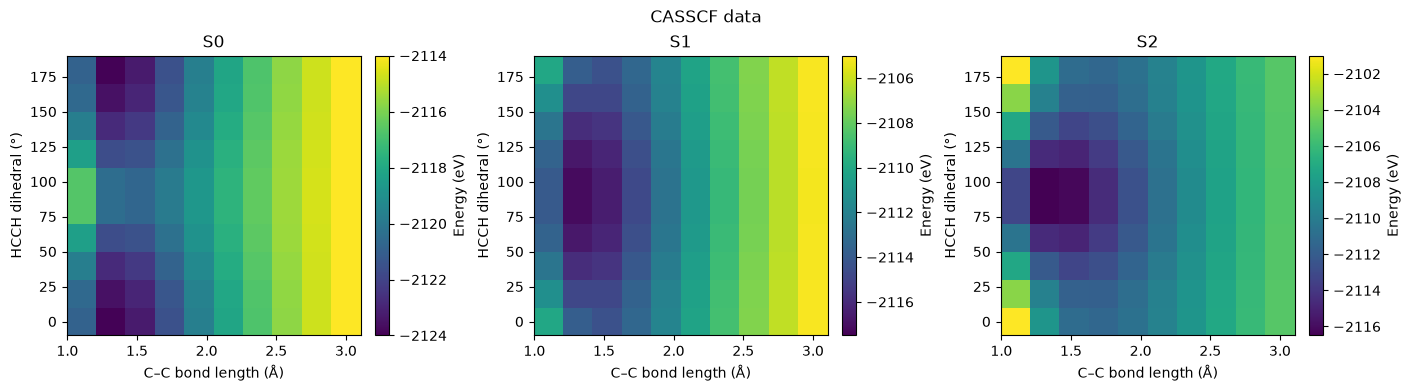

In [9]:
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np

XYZ_GRID = Path("/home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_101_grid.xyz")
ethene_atoms = ase.io.read(XYZ_GRID, index=":")

# The leading frame is the equilibrium reference; the remaining 100 frames form the 10 × 10 grid.
grid_atoms = ethene_atoms[1:]
energies = np.vstack([
    np.asarray(atoms.info["REF_energy"], dtype=float).reshape(-1)
    for atoms in grid_atoms
])
if energies.shape[1] != 3:
    raise ValueError(f"Expected three electronic states, got {energies.shape[1]}")

bond_lengths = np.asarray([atoms.get_distance(0, 1) for atoms in grid_atoms])
dihedrals = np.asarray([atoms.get_dihedral(2, 0, 1, 3) for atoms in grid_atoms])
x = np.unique(np.round(bond_lengths, 6))
y = np.unique(np.round(dihedrals, 6))
x_index = np.searchsorted(x, np.round(bond_lengths, 6))
y_index = np.searchsorted(y, np.round(dihedrals, 6))

if len(grid_atoms) != len(x) * len(y):
    raise ValueError("Grid geometries do not form a complete C–C/HCCH mesh")

surface = np.full((len(y), len(x), 3), np.nan)
surface[y_index, x_index] = energies
# Fixed limits match the augmented-grid heatmaps for direct comparison.
limits = [(-2124, -2114), (-2117.5, -2105), (-2116.5, -2101)]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
for state, ax in enumerate(axes):
    im = ax.pcolormesh(
        x, y, surface[..., state], shading="nearest", cmap="viridis",
        vmin=limits[state][0], vmax=limits[state][1],
    )
    ax.set(
        title=f"S{state}",
        xlabel="C–C bond length (Å)",
        ylabel="HCCH dihedral (°)",
    )
    fig.colorbar(im, ax=ax, label="Energy (eV)")

plt.suptitle("CASSCF data")
plt.show()
